# Greeks for Barrier and American Options with the COS Method

In the backward COS inductions of the previous chapters the spot never enters the recursion — $S_0$ appears only in the final projection. Price, delta and gamma are therefore three projections of the same coefficients $\hat V_k(t_1)$, with $H_k = \varphi_{\Delta t}(\omega_k)\,e^{i\omega_k(x_0-a)}$:

$$\Delta = -\frac{Ke^{-r\Delta t}}{S_0}\sum_k{}' \omega_k\,\mathrm{Im}(H_k)\,\hat V_k, \qquad
\Gamma = \frac{Ke^{-r\Delta t}}{S_0^2}\sum_k{}'\left(\omega_k\,\mathrm{Im}(H_k) - \omega_k^2\,\mathrm{Re}(H_k)\right)\hat V_k$$

— the European formulas from `cos_greeks.py` with the induced coefficients swapped in. {cite:t}`FangOosterlee2009AM` report exponential convergence for Bermudan delta and gamma; tree and LSMC Greeks are noisy by comparison. Vega and theta get no such shortcut ($\sigma$ and $T$ enter $\varphi$ at every step), so we bump those.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from utils import (_cos_chi, _cos_psi, _cos_payoff_coeffs, _compute_domain,
                   bs_call_price)
from cos_greeks import cos_greeks, bs_greeks_analytical


def gbm_cf(tau, r, sigma):
    return lambda u: np.exp(1j * u * (r - 0.5 * sigma**2) * tau - 0.5 * sigma**2 * u**2 * tau)


S0, K, H, T, r, sigma = 100.0, 100.0, 120.0, 1.0, 0.05, 0.2

Coefficient-returning versions of the two pricers — same recursions as before, stopped before the final projection. The barrier one is the FFT variant from the barrier chapter; the American one uses analytic terminal coefficients ($\chi_k, \psi_k$ on $[a,0]$) and needs the grid only for the early-exercise max.

In [2]:
def _mj(j, x1, x2, a, b):
    # m_j sequence, Fang-Oosterlee (2009) Eqs. (34)-(35)
    j = np.atleast_1d(j)
    bma = b - a
    out = np.empty(j.shape, dtype=complex)
    zero = (j == 0)
    out[zero] = 1j * np.pi * (x2 - x1) / bma
    jn = j[~zero]
    out[~zero] = (np.exp(1j * jn * np.pi * (x2 - a) / bma)
                  - np.exp(1j * jn * np.pi * (x1 - a) / bma)) / jn
    return out


def cos_barrier_uoc_coeffs(S0, K, H, T, r, sigma, N=256, M=12, R=0.0):
    # V^hat_k(t_1) of the discretely monitored UOC
    x0, h = np.log(S0 / K), np.log(H / K)
    assert x0 < h, "knocked out at t0"
    a, b = _compute_domain(x0, T, 10, sigma, r)
    h = min(h, b)
    dt = T / M
    k = np.arange(N)
    w = k * np.pi / (b - a)
    phi = np.exp(1j * w * (r - 0.5 * sigma**2) * dt - 0.5 * sigma**2 * w**2 * dt)
    psi_hb = (2.0 / (b - a)) * _cos_psi(k, h, b, a, b)
    Vk = (2.0 / (b - a)) * (_cos_chi(k, 0.0, h, a, b) - _cos_psi(k, 0.0, h, a, b))
    if R != 0.0:
        Vk = Vk + (R / K) * psi_hb

    mj = _mj(np.arange(1 - N, 2 * N), a, h, a, b)
    off = N - 1
    ms = np.zeros(2 * N, dtype=complex)
    ms[0] = mj[off]
    ms[1:N] = mj[off - 1::-1]             # m_{-1} .. m_{1-N}
    ms[N + 1:] = mj[off + N - 1:off:-1]   # m_{N-1} .. m_1
    mc = mj[off + 2 * N - 1:off - 1:-1] if off > 0 else mj[::-1]
    fft_ms, fft_mc = np.fft.fft(ms), np.fft.fft(mc)

    zeros = np.zeros(N)
    for m in range(M - 1, 0, -1):
        u = phi * Vk
        u[0] *= 0.5
        Msu = np.fft.ifft(fft_ms * np.fft.fft(np.concatenate([u, zeros])))[:N]
        Mcu = np.fft.ifft(fft_mc * np.fft.fft(np.concatenate([zeros, u])))[:N][::-1]
        Vk = np.exp(-r * dt) / np.pi * np.imag(Msu + Mcu)
        if R != 0.0:
            Vk = Vk + np.exp(-r * (T - m * dt)) * (R / K) * psi_hb
    return Vk, a, b

In [3]:
def cos_american_put_coeffs(S0, K, T, r, sigma, N=256, M=50):
    # V^hat_k(t_1); analytic terminal coeffs, grid only for the early-exercise max
    # strike-centered domain (04's convention) -- keeps the exercise grid static across spot bumps
    a, b = _compute_domain(0.0, T, 10, sigma, r)
    dt = T / M
    k = np.arange(N)
    w = k * np.pi / (b - a)
    phi = np.exp(1j * w * (r - 0.5 * sigma**2) * dt - 0.5 * sigma**2 * w**2 * dt)
    phi_re, phi_im = np.real(phi), np.imag(phi)

    x_grid = np.linspace(a, b, N)
    dx = (b - a) / (N - 1)
    theta_kj = np.outer(k, np.arange(N)) * np.pi / (N - 1)
    cos_grid, sin_grid = np.cos(theta_kj), np.sin(theta_kj)
    recon = phi_re[:, None] * cos_grid - phi_im[:, None] * sin_grid
    trap = np.ones(N); trap[0] = trap[-1] = 0.5
    exercise = np.maximum(1.0 - np.exp(x_grid), 0.0)

    Vk = _cos_payoff_coeffs(k, a, b, 'put')
    for m in range(M - 1, 0, -1):
        u = Vk.copy()
        u[0] *= 0.5
        cont = np.exp(-r * dt) * (u @ recon)
        Vk = (2.0 * dx / (b - a)) * (cos_grid @ (np.maximum(cont, exercise) * trap))
    return Vk, a, b

One projection function serves both products.

In [4]:
def cos_greeks_from_coeffs(S0, K, r, dt, cf_dt, Vk, a, b):
    # price/delta/gamma are three projections of the same coefficients
    x0 = np.log(S0 / K)
    w = np.arange(len(Vk)) * np.pi / (b - a)
    Hk = cf_dt(w) * np.exp(1j * w * (x0 - a))
    Hk[0] *= 0.5
    disc = np.exp(-r * dt)
    ReH, ImH = np.real(Hk), np.imag(Hk)
    return {'price': K * disc * np.sum(ReH * Vk),
            'delta': -(K * disc / S0) * np.sum(w * ImH * Vk),
            'gamma': (K * disc / S0**2) * np.sum((w * ImH - w**2 * ReH) * Vk)}

Two exact reductions first: a barrier that can't be hit is a European call, and a Bermudan put with one exercise date is a European put.

In [5]:
Vk, a, b = cos_barrier_uoc_coeffs(S0, K, 1e8, T, r, sigma, N=256, M=1)
g = cos_greeks_from_coeffs(S0, K, r, T, gbm_cf(T, r, sigma), Vk, a, b)
ref = cos_greeks(S0, K, T, r, gbm_cf(T, r, sigma), N=256, L=10, opt_type='call', std=sigma)
print(f"UOC(H=inf, M=1): delta {g['delta']:.10f}  vs european {ref['delta']:.10f}")

Vk, a, b = cos_american_put_coeffs(S0, K, T, r, sigma, N=256, M=1)
g = cos_greeks_from_coeffs(S0, K, r, T, gbm_cf(T, r, sigma), Vk, a, b)
bs = bs_greeks_analytical(S0, K, T, r, sigma, 'put')
print(f"Bermudan(M=1):   delta {g['delta']:.10f}  vs BS put   {bs['delta']:.10f}")

UOC(H=inf, M=1): delta 0.6368306512  vs european 0.6368306512
Bermudan(M=1):   delta -0.3631693488  vs BS put   -0.3631693488


Against independent references. For the barrier, bumping the spot re-centers the truncation domain, so the FD check exercises a genuinely different code path. The American keeps its domain strike-centered so the exercise grid doesn't move between bumps -- that makes its FD agreement near-tautological, and the CRR tree is the real referee there.

In [6]:
def binomial_american_put_greeks(S0, K, r, sigma, T, Nsteps=2000):
    # CRR; delta from step-1 nodes, gamma from step-2 nodes
    dt = T / Nsteps
    u = np.exp(sigma * np.sqrt(dt)); d = 1.0 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)
    j = np.arange(Nsteps + 1)
    V = np.maximum(K - S0 * u**(Nsteps - j) * d**j, 0.0)
    keep = {}
    for step in range(Nsteps - 1, -1, -1):
        j = np.arange(step + 1)
        S = S0 * u**(step - j) * d**j
        V = np.maximum(disc * (p * V[:-1] + (1 - p) * V[1:]), K - S)
        if step in (1, 2):
            keep[step] = (S.copy(), V.copy())
    S1, V1 = keep[1]; S2, V2 = keep[2]
    delta = (V1[0] - V1[1]) / (S1[0] - S1[1])
    d_up = (V2[0] - V2[1]) / (S2[0] - S2[1])
    d_dn = (V2[1] - V2[2]) / (S2[1] - S2[2])
    gamma = (d_up - d_dn) / (0.5 * (S2[0] - S2[2]))
    return {'price': V[0], 'delta': delta, 'gamma': gamma}


def barrier_price(s, N=512, M=12):
    Vk, a, b = cos_barrier_uoc_coeffs(s, K, H, T, r, sigma, N=N, M=M)
    return cos_greeks_from_coeffs(s, K, r, T / M, gbm_cf(T / M, r, sigma), Vk, a, b)['price']


def american_price(s, N=256, M=50):
    Vk, a, b = cos_american_put_coeffs(s, K, T, r, sigma, N=N, M=M)
    return cos_greeks_from_coeffs(s, K, r, T / M, gbm_cf(T / M, r, sigma), Vk, a, b)['price']


eps = 1e-4 * S0

Vk, a, b = cos_barrier_uoc_coeffs(S0, K, H, T, r, sigma, N=512, M=12)
gb = cos_greeks_from_coeffs(S0, K, r, T / 12, gbm_cf(T / 12, r, sigma), Vk, a, b)
d_fd = (barrier_price(S0 + eps) - barrier_price(S0 - eps)) / (2 * eps)
g_fd = (barrier_price(S0 + eps) - 2 * barrier_price(S0) + barrier_price(S0 - eps)) / eps**2
print(f"UOC (M=12):      delta {gb['delta']:>9.6f} (fd {d_fd:>9.6f})   gamma {gb['gamma']:>9.6f} (fd {g_fd:>9.6f})")

Vk, a, b = cos_american_put_coeffs(S0, K, T, r, sigma, N=1024, M=252)
ga = cos_greeks_from_coeffs(S0, K, r, T / 252, gbm_cf(T / 252, r, sigma), Vk, a, b)
binom = binomial_american_put_greeks(S0, K, r, sigma, T)
print(f"Am put (M=252):  delta {ga['delta']:>9.6f} (crr {binom['delta']:>9.6f})   gamma {ga['gamma']:>9.6f} (crr {binom['gamma']:>9.6f})")

UOC (M=12):      delta -0.010058 (fd -0.010058)   gamma -0.007936 (fd -0.007936)
Am put (M=252):  delta -0.410944 (crr -0.411087)   gamma  0.022986 (crr  0.022996)


How do the barrier Greeks behave as the spot approaches $H$?

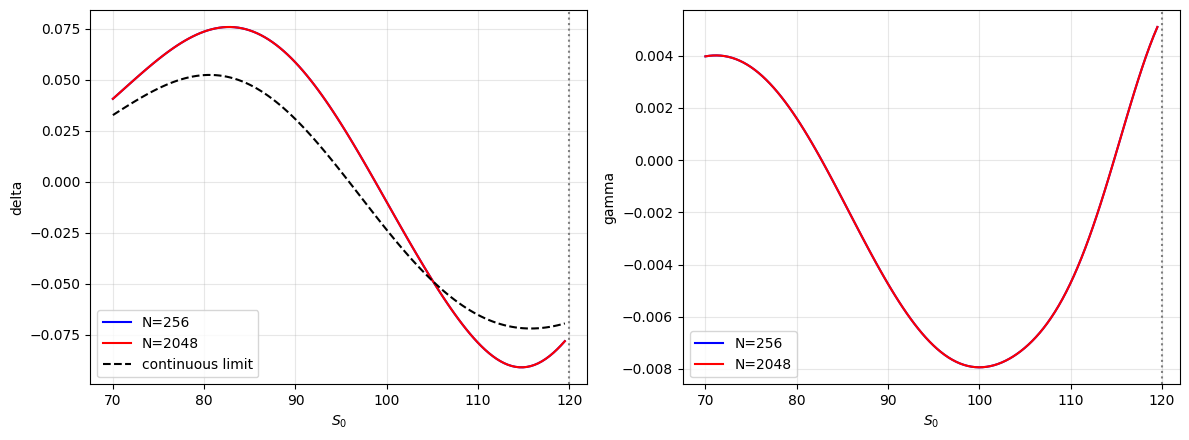

In [7]:
def trunc_call_bs(S0_, K_, H_, r_, sigma_, T_):
    # e^{-rT} E[(S_T-K)^+ 1_{S_T<H}]
    d2H = (np.log(S0_ / H_) + (r_ - 0.5 * sigma_**2) * T_) / (sigma_ * np.sqrt(T_))
    return (bs_call_price(S0_, K_, r_, sigma_, T_) - bs_call_price(S0_, H_, r_, sigma_, T_)
            - (H_ - K_) * np.exp(-r_ * T_) * norm.cdf(d2H))


def uoc_analytic(S0_, K_, H_, r_, sigma_, T_):
    # continuous limit via method of images
    a2 = 1.0 - 2.0 * r_ / sigma_**2
    return (trunc_call_bs(S0_, K_, H_, r_, sigma_, T_)
            - (S0_ / H_)**a2 * trunc_call_bs(H_**2 / S0_, K_, H_, r_, sigma_, T_))


S_grid = np.linspace(70, 119.5, 120)
M = 12
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for N, style in ((256, 'b-'), (2048, 'r-')):
    gs = []
    for s in S_grid:
        Vk, a, b = cos_barrier_uoc_coeffs(s, K, H, T, r, sigma, N=N, M=M)
        gs.append(cos_greeks_from_coeffs(s, K, r, T / M, gbm_cf(T / M, r, sigma), Vk, a, b))
    ax1.plot(S_grid, [g['delta'] for g in gs], style, lw=1.5, label=f'N={N}')
    ax2.plot(S_grid, [g['gamma'] for g in gs], style, lw=1.5, label=f'N={N}')

de = 1e-3
d_cont = [(uoc_analytic(s + de, K, H, r, sigma, T) - uoc_analytic(s - de, K, H, r, sigma, T)) / (2 * de)
          for s in S_grid]
ax1.plot(S_grid, d_cont, 'k--', lw=1.5, label='continuous limit')
for ax, name in ((ax1, 'delta'), (ax2, 'gamma')):
    ax.axvline(H, color='gray', ls=':')
    ax.set_xlabel('$S_0$')
    ax.set_ylabel(name)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

No drama near the barrier: $N=256$ and $N=2048$ land on the same curves (gamma at $S_0=118$ is 0.0037 at both), because the $t_0$ value is the $t_1$ value convolved with a Gaussian of width $\sigma\sqrt{\Delta t}\approx 0.058$ in log-space — the first monitoring date is a month away, and the $\varphi$ factor applies exactly that smoothing to the slowly decaying $\hat V_k$. The trouble we braced for lives in the continuous limit: the dashed delta steepens toward its jump at $H$ while the discrete-monitor delta stays tame. More monitoring dates would sharpen it.

For the American put, the projection gives the continuation-value Greeks. Where immediate exercise is optimal the option IS the payoff: delta $-1$, gamma $0$.

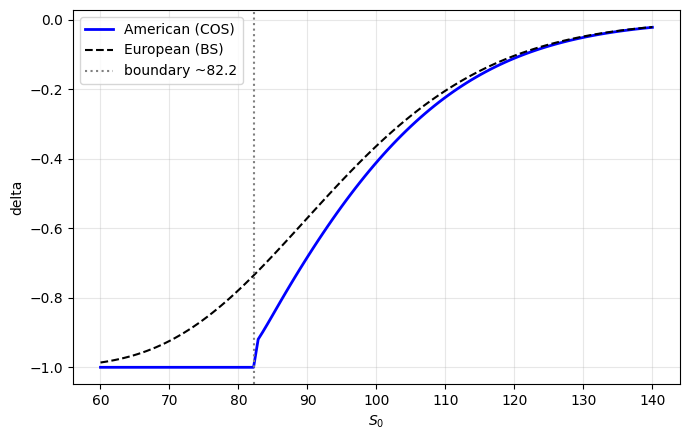

exercise boundary between 82.2 and 82.9


In [8]:
S_grid = np.linspace(60, 140, 120)
M, N = 50, 256
deltas, flags = [], []
for s in S_grid:
    Vk, a, b = cos_american_put_coeffs(s, K, T, r, sigma, N=N, M=M)
    g = cos_greeks_from_coeffs(s, K, r, T / M, gbm_cf(T / M, r, sigma), Vk, a, b)
    exercised = (K - s) > g['price']
    deltas.append(-1.0 if exercised else g['delta'])
    flags.append(exercised)
boundary = S_grid[np.where(np.array(flags))[0][-1]] if any(flags) else np.nan

d_eur = [bs_greeks_analytical(s, K, T, r, sigma, 'put')['delta'] for s in S_grid]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(S_grid, deltas, 'b-', lw=2, label='American (COS)')
ax.plot(S_grid, d_eur, 'k--', lw=1.5, label='European (BS)')
ax.axvline(boundary, color='gray', ls=':', label=f'boundary ~{boundary:.1f}')
ax.set_xlabel('$S_0$')
ax.set_ylabel('delta')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"exercise boundary between {boundary:.1f} and {boundary + (S_grid[1]-S_grid[0]):.1f}")

No analytic shortcut for vega and theta — bump the whole recursion.

In [9]:
es, eT = 1e-4, 1e-3

def bprice(sig, mat):
    Vk, a, b = cos_barrier_uoc_coeffs(S0, K, H, mat, r, sig, N=512, M=12)
    return cos_greeks_from_coeffs(S0, K, r, mat / 12, gbm_cf(mat / 12, r, sig), Vk, a, b)['price']

def aprice(sig, mat):
    Vk, a, b = cos_american_put_coeffs(S0, K, mat, r, sig, N=256, M=50)
    return cos_greeks_from_coeffs(S0, K, r, mat / 50, gbm_cf(mat / 50, r, sig), Vk, a, b)['price']

vega_b = (bprice(sigma + es, T) - bprice(sigma - es, T)) / (2 * es)
theta_b = (bprice(sigma, T - eT) - bprice(sigma, T)) / eT
vega_a = (aprice(sigma + es, T) - aprice(sigma - es, T)) / (2 * es)
theta_a = (aprice(sigma, T - eT) - aprice(sigma, T)) / eT

eb = 1e-3
vega_crr = (binomial_american_put_greeks(S0, K, r, sigma + eb, T)['price']
            - binomial_american_put_greeks(S0, K, r, sigma - eb, T)['price']) / (2 * eb)
theta_crr = (binomial_american_put_greeks(S0, K, r, sigma, T - eT)['price']
             - binomial_american_put_greeks(S0, K, r, sigma, T)['price']) / eT

print(f"UOC:    vega {vega_b:>9.4f}   theta {theta_b:>9.4f}")
print(f"Am put: vega {vega_a:>9.4f}   theta {theta_a:>9.4f}   (crr: {vega_crr:.4f}, {theta_crr:.4f})")

UOC:    vega  -15.0120   theta    1.4120
Am put: vega   37.4711   theta   -2.2276   (crr: 37.4853, -2.2387)


The up-and-out vega comes out negative and theta positive — more volatility mostly buys more knockouts at this barrier distance, and less time means fewer chances to get knocked out. Standard vanilla intuition inverts on both.

TODO: rho; forward-mode $d\hat V_k/d\sigma$ through the recursion (the envelope theorem kills the boundary-shift term for the American); barrier and Bermudan Greeks under `Heston_CF` — the projection formulas don't change.